<a href="https://colab.research.google.com/github/acla252/GEOG-761/blob/main/761_Lab_Two_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [4]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

In [5]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='gisci341-467221')

In [6]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [7]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [8]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2020-01-01', '2020-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median()

      .clip(aoi))







(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

1: In the above code, we are creating a composite from a set of images. These images have been filtered by region, date and also cloudy pixel percentage.Then the map() function masks out individual pixels that are marked as cloudy. and scales and returns the desired bands. Currently the .median() function is being used to find the median (non-masked) value at each pixel. Other options are:
.mean(), where the mean pixel value is used
.max(), where the maximum of the pixel values is used
.min(), where the minimum of the pixel values is used
.mozaic(), where the last valid pixel in a sequence of images is used
.qualityMozaic(band), where all bands from the image that has the highest value of a specified quality band is used
.reduce(ee.Reducer.percentile()) is like a .median() function, but with more options over the percentiles desired
.first(), where the first image is used
.last(), where the last image is used
.reduce(ee.Reducer.mode()), where the most common value at each pixel is used




In [9]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [10]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

It uses land-cover data from 2020.

In [11]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped).addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [12]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.02669999934732914, B3=0.028599999845027924, B4=0.007199999876320362, B8=0.006099999882280827
Sample 2: Class=8, B2=0.037300001829862595, B3=0.024399999529123306, B4=0.007300000172108412, B8=0.0034000000450760126
Sample 3: Class=1, B2=0.017899999395012856, B3=0.03869999945163727, B4=0.023983333259820938, B8=0.24060000479221344
Sample 4: Class=8, B2=0.04190000146627426, B3=0.03344999998807907, B4=0.007249999791383743, B8=0.0034000000450760126
Sample 5: Class=1, B2=0.014720000326633453, B3=0.02461666613817215, B4=0.01642500050365925, B8=0.28949999809265137
Sample 6: Class=5, B2=0.11460000276565552, B3=0.10014999657869339, B4=0.11429999768733978, B8=0.15520000457763672
Sample 7: Class=1, B2=0.03290000185370445, B3=0.0544000007212162, B4=0.050850000232458115, B8=0.2685000002384186
Sample 8: Class=8, B2=0.041600000113248825, B3=0.02876250073313713, B4=0.009920000098645687, B8=0.0045111109502613544
Sample 9: Class=8, B2=0.03420000150799751, 

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

For Sample 2, the Class is 8, which corresponds to the original class of 80 in the ESA/WorldCover/v100/2020 dataset, which the documentation tell us is "Permanent water bodies". (reference https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100#bands )


We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [13]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [14]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [15]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [16]:
# Classified image viz
Map = geemap.Map()
Map.centerObject(aoi, 10)
# Use one ESA WorldCover palette for both layers.
# Palette order follows the current remapping:
# 1=tree, 2=shrub, 3=grass, 4=cropland, 5=built-up,
# 6=bare/sparse, 7=snow/ice, 8=water, 9=wetland, 10=moss/lichen.
landcover_vis = {
    'min': 1,
    'max': 10,
    'palette': [
        '006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000',
        'b4b4b4', 'f0f0f0', '0064c8', '0096a0', 'fae6a0'
    ]
}

# Force both images to contain exactly one band and give that band the same name.
classified_single = classified.select([0]).rename('landcover_class')
reference_single = landcover_remapped.select([0]).rename('landcover_class')

Map.addLayer(classified_single, landcover_vis, 'Classified')
Map.addLayer(reference_single, landcover_vis, 'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

The ESA landcover map and our classified results appear broadly similar. However the ESA landcover has more continuous regions that appear more well defined. In contrast, our classified results are more noisy and have a "salt and pepper' appearance. This speckled classification noise is because the random forest classifier calculates a result from the spectral values for each individual pixel, without considering the neighbouring pixels or spatial groupings. Small differences in the Sentinel 2 data, such as small physical features, sensor noise, unusual vegetation, etc can cause this 'salt and pepper' effect.

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       209        0       38        0        4        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        38        0      128        0        2        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        5        0       38        0        0   
Actual 60         0        0        1        0        6        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         1        0        0        0        1        0        0   
Actual 90         2        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


In [18]:

# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       209        0       38        0        4        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        38        0      128        0        2        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        5        0       38        0        0   
Actual 60         0        0        1        0        6        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         1        0        0        0        1        0        0   
Actual 90         2        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

2020 Test Overall Accuracy: 90.76%


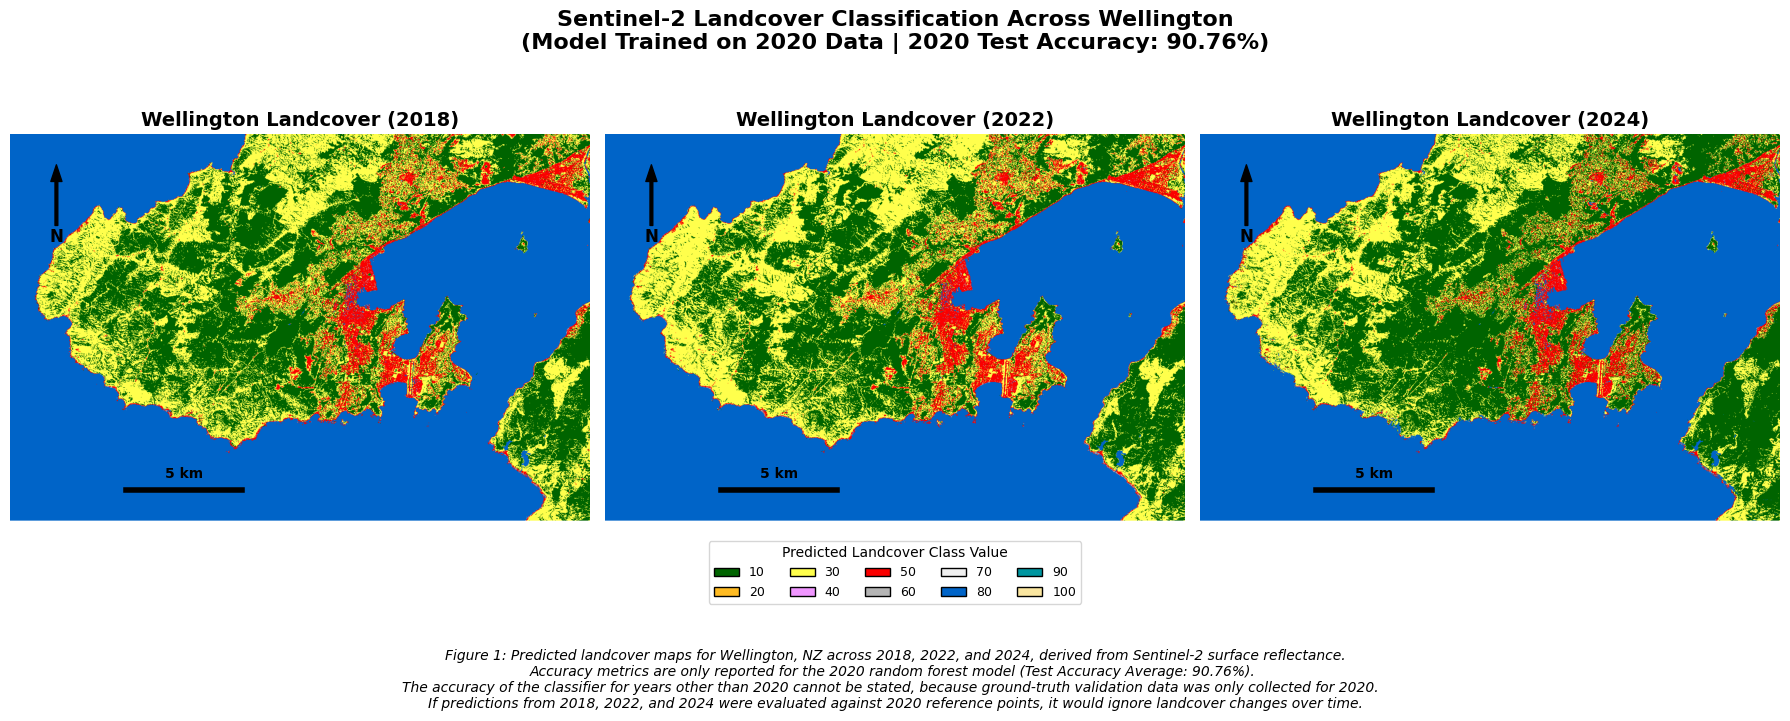

In [24]:
# Question (5)
# Wellington landcover maps for 2018,2022,2024
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import urllib.request
from PIL import Image
import numpy as np

# Define a function to get S2 data for a given year and aoi
def get_s2(year, aoi ) :
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    # Now build the clean collection with selected bands
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate(start_date, end_date)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median()
      .clip(aoi))
    return s2


# Evaluate 2020 Test Accuracy using the trained classifier
testPixels = test.classify(classifier, "predicted")

# Get confusion matrix and overall accuracy directly from Earth Engine
error_matrix = testPixels.errorMatrix("Map_remapped", "predicted")
test_accuracy_2020 = error_matrix.accuracy().getInfo()
print(f"2020 Test Overall Accuracy: {test_accuracy_2020 * 100:.2f}%")


# Classify each of the target years (2018, 2022, 2024)
years = [2018, 2022, 2024]
classified_maps = {}

for yr in years:
    img = get_s2(yr, aoi)
    # Classify the yearly composite using the trained 2020 Random Forest classifier
    classified_maps[yr] = img.classify(classifier)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, yr in zip(axes, years):
    # Ask GEE for a thumbnail image download for visualization
    thumb_url = classified_maps[yr].getThumbURL(
        {
            "region": aoi,
            "dimensions": 1200,
            "min": 1,
            "max": 10,
            "palette": landcover_vis["palette"],
        }
    )

    # Display image in subplot panel
    # Download the image from the URL
    with urllib.request.urlopen(thumb_url) as url_file:
        img_data = np.array(Image.open(url_file))
    ax.imshow(img_data)
    ax.set_title(f"Wellington Landcover ({yr})", fontsize=14, fontweight="bold")

    # North arrow
    ax.annotate(
        'N',
        xy=(0.08, 0.92),
        xytext=(0.08, 0.72),
        xycoords='axes fraction',
        ha='center',
        fontsize=12,
        fontweight='bold',
        arrowprops=dict(
            facecolor='black',
            width=2,
            headwidth=8
        )
    )

    # 5 km scale bar
    # Scale-bar length as a fraction of the AOI width
    aoi_width_km = (174.9 - 174.6) * 111.32 * np.cos(np.deg2rad(-41.3))
    scale_fraction = 5 / aoi_width_km
    x0, y0 = 0.20, 0.08
    ax.plot(
        [x0, x0 + scale_fraction],
        [y0, y0],
        transform=ax.transAxes,
        color='black',
        linewidth=4
    )
    ax.text(
        x0 + scale_fraction / 2,
        y0 + 0.025,
        '5 km',
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

    ax.axis("off")

# Add text banner highlighting 2020 Overall Test Accuracy
fig.suptitle(
    f"Sentinel-2 Landcover Classification Across Wellington\n"
    f"(Model Trained on 2020 Data | 2020 Test Accuracy: {test_accuracy_2020*100:.2f}%)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)



# LEGEND

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=f"#{color}", edgecolor='black', label=label)
    for color, label in zip(landcover_vis["palette"], label_names)
]

fig.legend(
    handles=legend_handles,
    title="Predicted Landcover Class Value",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=5,
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

# Caption text at the bottom of the figure
caption_text = (
    f"Figure 1: Predicted landcover maps for Wellington, NZ across 2018, 2022, and 2024, derived from Sentinel-2 surface reflectance.\n"
    f"Accuracy metrics are only reported for the 2020 random forest model (Test Accuracy Average: {test_accuracy_2020*100:.2f}%). \n"
    f"The accuracy of the classifier for years other than 2020 cannot be stated, because ground-truth validation data was only collected for 2020.  \n"
    f"If predictions from 2018, 2022, and 2024 were evaluated against 2020 reference points, it would ignore landcover changes over time."
)

plt.figtext(
    0.5,
    -0.14,
    caption_text,
    ha="center",
    fontsize=10,
    style="italic",
    wrap=True,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# SVMs Applied to Satellite Data

In [25]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       209        0       38        0        4        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        38        0      128        0        2        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        5        0       38        0        0   
Actual 60         0        0        1        0        6        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         1        0        0        0        1        0        0   
Actual 90         2        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [26]:
import zipfile
import geopandas as gpd
import os
from google.colab import files

# If test.zip already exists in Colab, use it.
# Otherwise ask the user to upload a ZIP file.
if os.path.exists("lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP.zip"):
    uploaded_filename = "lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP.zip"
    print("Using existing zip")
else:
    uploaded = files.upload()  # Expects a ZIP
    uploaded_filename = list(uploaded.keys())[0]
    print(f"Using uploaded file: {uploaded_filename}")

# Unzip
with zipfile.ZipFile(uploaded_filename, 'r') as zip_ref:
    zip_ref.extractall()

# Read shapefile
gdf = gpd.read_file("lcdb-v60-land-cover-database-version-60-mainland-new-zealand.shp")
print(gdf.head())

Saving lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP (1).zip to lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP (1).zip
Using uploaded file: lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP (1).zip
              Name_2023             Name_2018             Name_2012  \
0       Sand and Gravel       Sand and Gravel       Sand and Gravel   
1  Manuka and/or Kanuka  Manuka and/or Kanuka  Manuka and/or Kanuka   
2     Indigenous Forest     Indigenous Forest     Indigenous Forest   
3       Sand and Gravel       Sand and Gravel       Sand and Gravel   
4       Sand and Gravel       Sand and Gravel       Sand and Gravel   

              Name_2008             Name_2001             Name_1996  \
0       Sand and Gravel       Sand and Gravel       Sand and Gravel   
1  Manuka and/or Kanuka  Manuka and/or Kanuka  Manuka and/or Kanuka   
2     Indigenous Forest     Indigenous Forest     Indigenous Forest   
3       Sand and Gravel 

In [27]:
# Define area of interest (Around Great Barrier Island)

aoi_coords = [175.27,-36.36,175.57,-36.01]
aoi = ee.Geometry.Rectangle(aoi_coords)
Map = geemap.Map(center=[-36.23, 175.37], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right...
#Map

# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-36.23, 175.37], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

Load the LCDB v6.0 2023/24 polygons and the austral-summer 2023/24 Sentinel-2 composite.
Use an RBF support-vector machine for the classifier.

In [28]:
from shapely.geometry import box
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import urllib.request
from PIL import Image
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# The uploaded LCDB v6.0 shapefile
required_lcdb_fields = {'Class_2023', 'Name_2023'}

# Use the Great Barrier Island bounds already established

# Clip in the source CRS first so the full national layer is not reprojected.
aoi_gdf_ex6 = gpd.GeoDataFrame(
    geometry=[box(*aoi_coords)],
    crs='EPSG:4326'
).to_crs(gdf.crs)

gbi_lcdb = gpd.clip(
    gdf[['Class_2023', 'Name_2023', 'geometry']],
    aoi_gdf_ex6
).copy()

gbi_lcdb = gbi_lcdb[
    gbi_lcdb.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])
].dropna(subset=['Class_2023', 'Name_2023', 'geometry'])

# Repair/simplify the local polygons in metres, then return them to WGS84 for EE.
gbi_lcdb = gbi_lcdb.to_crs('EPSG:2193')
gbi_lcdb['geometry'] = (
    gbi_lcdb.geometry.buffer(0).simplify(5, preserve_topology=True)
)
gbi_lcdb = gbi_lcdb[~gbi_lcdb.geometry.is_empty].to_crs('EPSG:4326')

# Convert the nominal LCDB codes into consecutive integer IDs for classification.
gbi_lcdb['lcdb_code'] = pd.to_numeric(
    gbi_lcdb['Class_2023'], errors='coerce'
)
gbi_lcdb = gbi_lcdb.dropna(subset=['lcdb_code'])
gbi_lcdb['lcdb_code'] = gbi_lcdb['lcdb_code'].astype(int)

class_table_ex6 = (
    gbi_lcdb[['lcdb_code', 'Name_2023']]
    .drop_duplicates(subset='lcdb_code')
    .sort_values('lcdb_code')
    .reset_index(drop=True)
)
code_to_id_ex6 = {
    int(code): class_id
    for class_id, code in enumerate(class_table_ex6['lcdb_code'])
}
gbi_lcdb['lcdb_class'] = (
    gbi_lcdb['lcdb_code'].map(code_to_id_ex6).astype(int)
)

print(f"LCDB polygons retained: {len(gbi_lcdb):,}")
print("LCDB classes present inside the AOI:")
display(class_table_ex6)


LCDB polygons retained: 558
LCDB classes present inside the AOI:


,lcdb_code,Name_2023
0,1,Built-up Area (settlement)
1,2,Urban Parkland/Open Space
2,5,Transport Infrastructure
3,6,Surface Mine or Dump
4,10,Sand and Gravel
5,12,Landslide
6,16,Gravel and Rock
7,20,Lake or Pond
8,21,River
9,22,Estuarine Open Water


In [32]:
# Get the S2 data and do the training

predictor_bands_ex6 = [
    'B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI',
    # Try some more bands
    'B5', 'B6', 'B7', 'B8A','NDMI', 'NDBI'
]

# I've decided to use the SCL cloud masking band instead of QA60, since it seems to work better
def prepare_s2_ex6(image):
    # Mask unsuitable S2 pixels and add vegetation/water indices.
    scl = image.select('SCL')
    clear = (
        scl.neq(0)   # no data
        .And(scl.neq(1))   # saturated/defective
        .And(scl.neq(3))   # cloud shadow
        .And(scl.neq(8))   # medium-probability cloud
        .And(scl.neq(9))   # high-probability cloud
        .And(scl.neq(10))  # cirrus
        .And(scl.neq(11))  # snow/ice
    )
    # try the QA60 bits as well?
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask2 = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    clear = clear.And(mask2)

    reflectance = (
        image.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'B5', 'B6', 'B7', 'B8A'])
        .divide(10000)
    )
    # These derived indices can improve the overall accuracy
    ndvi = reflectance.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = reflectance.normalizedDifference(['B3', 'B8']).rename('NDWI')
    ndmi = reflectance.normalizedDifference(['B8', 'B11']).rename('NDMI')
    ndbi = reflectance.normalizedDifference(['B11', 'B8']).rename('NDBI')
    return (
        reflectance.addBands([ndvi, ndwi, ndmi,ndbi])
        .updateMask(clear)
        .copyProperties(image, ['system:time_start'])
    )

# Austral summer 2023/24: the end date in filterDate is exclusive.
s2_collection_ex6 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2023-10-01', '2024-05-01')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
    .map(prepare_s2_ex6)
    # .map(mask_s2_clouds)
    #.median()
)

scene_count_ex6 = s2_collection_ex6.size().getInfo()
if scene_count_ex6 == 0:
    raise RuntimeError(
        "No Sentinel-2 scenes passed the filters. Increase the scene-level "
        "cloud threshold, while retaining the pixel-level SCL mask."
    )

s2_summer_ex6 = (
    s2_collection_ex6.median()
    .select(predictor_bands_ex6)
    .clip(aoi)
)
print(f"Sentinel-2 scenes in the summer composite: {scene_count_ex6}")

# Send only the clipped, simplified Great Barrier polygons to Earth Engine.
gbi_upload_ex6 = gbi_lcdb[
    ['lcdb_class', 'Name_2023', 'geometry']
].copy()
lcdb_fc_ex6 = geemap.gdf_to_ee(gbi_upload_ex6, geodesic=False)

# Rasterize the LCDB polygon labels. Pixels outside LCDB polygons remain masked.
lcdb_labels_ex6 = (
    lcdb_fc_ex6
    .reduceToImage(['lcdb_class'], ee.Reducer.first())
    .rename('lcdb_class')
    .toInt()
    .clip(aoi)
)

# Sample pixels per LCDB class.
raw_samples_ex6 = (
    s2_summer_ex6.addBands(lcdb_labels_ex6)
    #.stratifiedSample(
    #    numPoints=100,
    #    classBand='lcdb_class',
    #    region=aoi,
    #    scale=10,
    #    seed=111,
    #    geometries=True,
    #    tileScale=4
    #)
    .sample(
        region=aoi,
        scale=10,
        numPixels=40000,
        seed=111,
        geometries=True,
        tileScale=4
    )
)

sample_histogram_ex6 = raw_samples_ex6.aggregate_histogram(
    'lcdb_class'
).getInfo()
sample_counts_ex6 = {
    int(float(class_id)): int(count)
    for class_id, count in sample_histogram_ex6.items()
}

# Very rare classes cannot support a meaningful train/test split.
minimum_samples_ex6 = 20
eligible_old_ids_ex6 = sorted(
    class_id
    for class_id, count in sample_counts_ex6.items()
    if count >= minimum_samples_ex6
)
omitted_old_ids_ex6 = sorted(
    class_id
    for class_id, count in sample_counts_ex6.items()
    if count < minimum_samples_ex6
)

if len(eligible_old_ids_ex6) < 2:
    raise RuntimeError(
        "Fewer than two LCDB classes have enough valid Sentinel-2 samples."
    )

id_to_name_ex6 = (
    gbi_lcdb[['lcdb_class', 'Name_2023']]
    .drop_duplicates(subset='lcdb_class')
    .set_index('lcdb_class')['Name_2023']
    .to_dict()
)
model_class_names_ex6 = [
    id_to_name_ex6[class_id] for class_id in eligible_old_ids_ex6
]

if omitted_old_ids_ex6:
    print("Classes omitted because too few pixels were sampled:")
    for class_id in omitted_old_ids_ex6:
        print(
            f"  {id_to_name_ex6[class_id]}: "
            f"{sample_counts_ex6[class_id]} pixels"
        )

# Re-number only the modeled classes from 0..n-1, as required by the classifier.
eligible_ids_ee_ex6 = ee.List(eligible_old_ids_ex6)
samples_ex6 = (
    raw_samples_ex6
    .filter(ee.Filter.inList('lcdb_class', eligible_old_ids_ex6))
    .map(
        lambda feature: feature.set(
            'model_class',
            eligible_ids_ee_ex6.indexOf(feature.get('lcdb_class'))
        )
    )
    .randomColumn('split', seed=761)
)

# 70% training, 20% validation, 10% testing
training_ex6 = samples_ex6.filter(ee.Filter.lt('split', 0.70))
validation_ex6 = samples_ex6.filter(ee.Filter.And(
        ee.Filter.gte('split', 0.70),
        ee.Filter.lt('split', 0.90)))
testing_ex6 = samples_ex6.filter(ee.Filter.gte('split', 0.90))

svm_ex6 = ee.Classifier.libsvm(
    # svmType='C_SVC',
    kernelType='RBF',
    gamma=5,
    cost=500
).train(
    features=training_ex6,
    classProperty='model_class',
    inputProperties=predictor_bands_ex6
)

# Apply the trained model to validation and test data
validated_ex6 = validation_ex6.classify(svm_ex6)
tested_ex6 = testing_ex6.classify(svm_ex6)

class_order_ex6 = ee.List.sequence(
    0, len(model_class_names_ex6) - 1
)

# Validation confusion matrix
validation_matrix_ex6 = validated_ex6.errorMatrix(
    'model_class',
    'classification',
    class_order_ex6
)

# Test confusion matrix
test_matrix_ex6 = tested_ex6.errorMatrix(
    'model_class',
    'classification',
    class_order_ex6
)

# Accuracies
validation_accuracy_ex6 = float( validation_matrix_ex6.accuracy().getInfo())
overall_accuracy_ex6 = float(test_matrix_ex6.accuracy().getInfo())

# Create the test confusion matrix for display
confusion_array_ex6 = np.asarray( test_matrix_ex6.array().getInfo(), dtype=int)

# Sample counts
training_count_ex6 = training_ex6.size().getInfo()
validation_count_ex6 = validation_ex6.size().getInfo()
testing_count_ex6 = testing_ex6.size().getInfo()

print(f"Training pixels: {training_count_ex6:,}")
print(f"Validation pixels: {validation_count_ex6:,}")
print(f"Held-out test pixels: {testing_count_ex6:,}")

print( f"Validation overall accuracy: " f"{validation_accuracy_ex6:.3f}")
print( f"Test overall accuracy: " f"{overall_accuracy_ex6:.3f}")

display(
    pd.DataFrame(
        confusion_array_ex6,
        index=[
            f"Actual: {name}"
            for name in model_class_names_ex6
        ],
        columns=[
            f"Predicted: {name}"
            for name in model_class_names_ex6
        ]
    )
)

# Classify the summer composite and mask the ocean using the LCDB coverage.
classified_ex6 = (
    s2_summer_ex6
    .classify(svm_ex6)
    .select([0])
    .rename('landcover_class')
    .updateMask(lcdb_labels_ex6.mask())
)


# LCDB v6.0 colours
lcdb_colours_ex6 = {
    'Built-up Area (settlement)': '#9C9C9C',
    'Surface Mines and Dumps': '#704489',
    'Transport Infrastructure': '#A80000',
    'Urban Parkland/Open Space': '#688578',
    'Sand and Gravel': '#FFFF73',
    'Landslide': '#CA7AF5',
    'Alpine Grass/Herbfield': '#ABCD66',
    'Gravel and Rock': '#9CBA9C',
    'Permanent Snow and Ice': '#DBD4FF',
    'Lake or Pond': '#BEE8FF',
    'River': '#BEE8FF',
    'Estuarine Open Water': '#D6F5E8',
    'Short-rotation Cropland': '#FFD37F',
    'Orchard Vineyard and Other Perennial Crops': '#E69800',
    'High Producing Exotic Grassland': '#BEFF8C',
    'Low Producing Grassland': '#A3D400',
    'Tall Tussock Grassland': '#E6E68C',
    'Depleted Grassland': '#D2D25A',
    'Herbaceous Freshwater Vegetation': '#C2FFD6',
    'Herbaceous Saline Vegetation': '#DEF5DE',
    'Flaxland': '#7AF5CA',
    'Fernland': '#705C00',
    'Gorse and/or Broom': '#7D690F',
    'Manuka and/or Kanuka': '#8C7922',
    'Broadleaved Indigenous Hardwoods': '#A8994F',
    'Sub Alpine Shrubland': '#B8AB6A',
    'Mixed Exotic Shrubland': '#C4BB89',
    'Matagouri or Grey Scrub': '#D4CDAE',
    'Forest - Harvested': '#A1AD61',
    'Deciduous Hardwoods': '#477F00',
    'Indigenous Forest': '#284600',
    'Exotic Forest': '#38A800',
    'Mangrove': '#448989'
}

palette_ex6 = [
    lcdb_colours_ex6[name]
    for name in model_class_names_ex6
]



Sentinel-2 scenes in the summer composite: 42
Classes omitted because too few pixels were sampled:
  Urban Parkland/Open Space: 7 pixels
  Transport Infrastructure: 2 pixels
  Landslide: 5 pixels
  River: 4 pixels
  Orchard, Vineyard or Other Perennial Crop: 3 pixels
  Forest - Harvested: 8 pixels
Training pixels: 7,868
Validation pixels: 2,176
Held-out test pixels: 1,160
Validation overall accuracy: 0.662
Test overall accuracy: 0.648


,Predicted: Built-up Area (settlement),Predicted: Sand and Gravel,Predicted: Gravel and Rock,Predicted: Estuarine Open Water,Predicted: High Producing Exotic Grassland,Predicted: Low Producing Grassland,Predicted: Herbaceous Freshwater Vegetation,Predicted: Herbaceous Saline Vegetation,Predicted: Gorse and/or Broom,Predicted: Manuka and/or Kanuka,Predicted: Broadleaved Indigenous Hardwoods,Predicted: Indigenous Forest,Predicted: Mangrove,Predicted: Exotic Forest
Actual: Built-up Area (settlement),0,0,0,0,0,0,0,0,0,0,0,0,0,0
Actual: Sand and Gravel,1,11,0,0,2,0,0,0,0,9,0,0,0,0
Actual: Gravel and Rock,0,2,0,0,0,0,0,0,0,1,0,0,0,0
Actual: Estuarine Open Water,0,0,0,5,0,0,0,0,0,1,0,0,0,0
Actual: High Producing Exotic Grassland,0,3,0,0,40,2,1,0,0,15,0,0,0,0
Actual: Low Producing Grassland,0,3,0,0,6,1,0,0,0,6,0,0,0,0
Actual: Herbaceous Freshwater Vegetation,0,0,0,0,0,0,5,0,0,7,0,0,0,0
Actual: Herbaceous Saline Vegetation,0,0,0,0,0,0,0,4,0,4,0,0,0,0
Actual: Gorse and/or Broom,0,0,0,0,1,0,0,0,0,1,0,0,0,0
Actual: Manuka and/or Kanuka,0,4,0,1,5,0,1,1,0,518,8,39,0,0


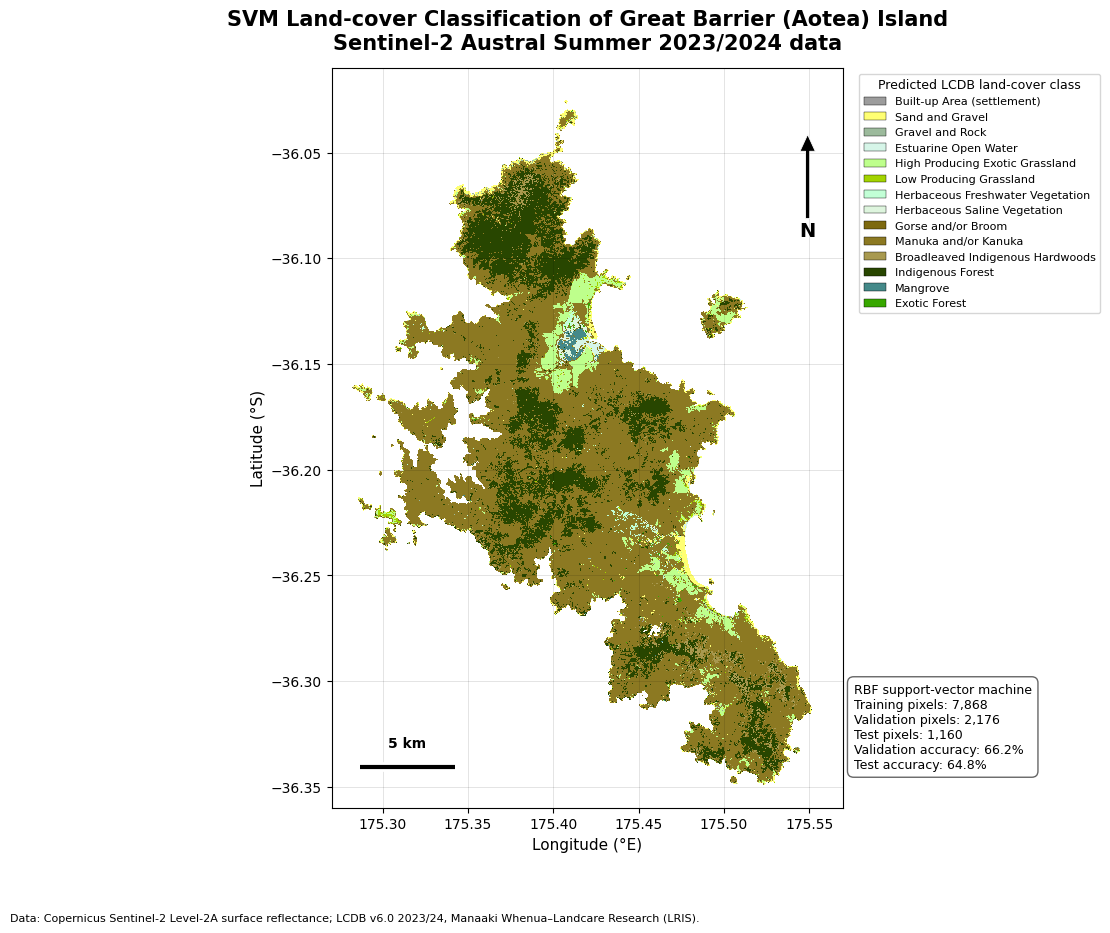

Saved publication figure to: Exercise6_Great_Barrier_SVM.png


In [34]:
# Make the pretty map
# Download the guaranteed single-band classification using the model palette.
thumbnail_url_ex6 = classified_ex6.getThumbURL({
    'region': aoi,
    'dimensions': 1600,
    'format': 'png',
    'min': 0,
    'max': len(model_class_names_ex6) - 1,
    'palette': palette_ex6
})
with urllib.request.urlopen(thumbnail_url_ex6) as response:
    classified_png_ex6 = np.asarray(Image.open(response).convert('RGBA'))

# Use the client-side aoi_coords variable instead of calling server-side .bounds()
xmin_ex6, ymin_ex6, xmax_ex6, ymax_ex6 = aoi_coords
mean_latitude_ex6 = (ymin_ex6 + ymax_ex6) / 2

fig_ex6, ax_ex6 = plt.subplots(figsize=(14, 10))
ax_ex6.imshow(
    classified_png_ex6,
    extent=[xmin_ex6, xmax_ex6, ymin_ex6, ymax_ex6],
    origin='upper',
    interpolation='nearest'
)

# Correct the local longitude/latitude display ratio.
ax_ex6.set_aspect(1 / np.cos(np.deg2rad(mean_latitude_ex6)))
ax_ex6.set_xlim(xmin_ex6, xmax_ex6)
ax_ex6.set_ylim(ymin_ex6, ymax_ex6)
ax_ex6.set_xlabel('Longitude (°E)', fontsize=11)
ax_ex6.set_ylabel('Latitude (°S)', fontsize=11)
ax_ex6.grid(color='black', alpha=0.15, linewidth=0.5)

# North arrow.
ax_ex6.annotate(
    'N',
    xy=(0.93, 0.91),
    xytext=(0.93, 0.78),
    xycoords='axes fraction',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold',
    arrowprops=dict(
        facecolor='black',
        edgecolor='white',
        linewidth=0.6,
        width=3,
        headwidth=11
    )
)

# Five-kilometre scale bar, converted to longitude degrees at this latitude.
scale_km_ex6 = 5
km_per_lon_degree_ex6 = 111.32 * np.cos(
    np.deg2rad(mean_latitude_ex6)
)
scale_degrees_ex6 = scale_km_ex6 / km_per_lon_degree_ex6
scale_x_ex6 = xmin_ex6 + 0.055 * (xmax_ex6 - xmin_ex6)
scale_y_ex6 = ymin_ex6 + 0.055 * (ymax_ex6 - ymin_ex6)

ax_ex6.plot(
    [scale_x_ex6, scale_x_ex6 + scale_degrees_ex6],
    [scale_y_ex6, scale_y_ex6],
    color='white',    linewidth=7,
    solid_capstyle='butt'
)
ax_ex6.plot(
    [scale_x_ex6, scale_x_ex6 + scale_degrees_ex6],
    [scale_y_ex6, scale_y_ex6],
    color='black',
    linewidth=3,
    solid_capstyle='butt'
)
ax_ex6.text(
    scale_x_ex6 + scale_degrees_ex6 / 2,
    scale_y_ex6 + 0.008,
    f'{scale_km_ex6} km',
    ha='center',
    va='bottom',
    fontsize=10,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5)
)

# Legend uses the exact class-to-color mapping supplied to Earth Engine.
legend_handles_ex6 = [
    Patch(
        facecolor=palette_ex6[class_id],
        edgecolor='black',
        linewidth=0.3,
        label=class_name
    )
    for class_id, class_name in enumerate(model_class_names_ex6)
]
ax_ex6.legend(
    handles=legend_handles_ex6,
    title='Predicted LCDB land-cover class',
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

performance_text_ex6 = (
    'RBF support-vector machine\n'
    f'Training pixels: {training_count_ex6:,}\n'
    f'Validation pixels: {validation_count_ex6:,}\n'
    f'Test pixels: {testing_count_ex6:,}\n'
    f'Validation accuracy: {validation_accuracy_ex6:.1%}\n'
    f'Test accuracy: {overall_accuracy_ex6:.1%}'
)
ax_ex6.text(
    1.02,
    0.05,
    performance_text_ex6,
    transform=ax_ex6.transAxes,
    ha='left',
    va='bottom',
    fontsize=9,
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='0.4'
    )
)

ax_ex6.set_title(
    'SVM Land-cover Classification of Great Barrier (Aotea) Island\n'
    'Sentinel-2 Austral Summer 2023/2024 data',
    fontsize=15,
    fontweight='bold',
    pad=14
)

fig_ex6.subplots_adjust(right=0.72, bottom=0.14, top=0.88)
fig_ex6.text(
    0.01,
    0.025,
    'Data: Copernicus Sentinel-2 Level-2A surface reflectance; '
    'LCDB v6.0 2023/24, Manaaki Whenua–Landcare Research (LRIS).',
    ha='left',
    va='bottom',
    fontsize=8
)

exercise6_output = 'Exercise6_Great_Barrier_SVM.png'
fig_ex6.savefig(
    exercise6_output,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print(f"Saved publication figure to: {exercise6_output}")

In [31]:
# Lets view the SVM classification vs LCDB reference land cover

# Convert the original LCDB class IDs to the same 0..n-1 numbering
# used by the SVM output, so both layers use exactly the same colours.
lcdb_true_ex6 = lcdb_labels_ex6.remap(
    eligible_old_ids_ex6,
    list(range(len(eligible_old_ids_ex6)))
)

landcover_vis_ex6 = {
    'min': 0,
    'max': len(model_class_names_ex6) - 1,
    'palette': palette_ex6
}

# Create interactive GIS map
Map_compare_ex6 = geemap.Map(
    center=[
        (aoi_coords[1] + aoi_coords[3]) / 2,
        (aoi_coords[0] + aoi_coords[2]) / 2
    ],
    zoom=11
)

# Add the two toggleable land-cover layers
Map_compare_ex6.addLayer(
    classified_ex6,
    landcover_vis_ex6,
    'SVM predicted land cover',
    True
)

Map_compare_ex6.addLayer(
    lcdb_true_ex6,
    landcover_vis_ex6,
    'LCDB v6.0 2023/24 reference land cover',
    True
)

Map_compare_ex6

Map(center=[-36.185, 175.42000000000002], controls=(WidgetControl(options=['position', 'transparent_bg'], posi…